In [40]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [41]:
import sys

sys.path.append('../scripts')

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
import json

In [43]:
import matplotlib as mpl
mpl.rcParams["font.family"] = "monospace"

In [57]:
def plot_model_comparison(
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_path="../figures",
    save_name="ood_summary"
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Compute global y-limits
    ymin = df[metrics].min().min() * 0.3
    ymax = df[metrics].max().max() * 1.05

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))
    n_deg = df["n_deg"].iloc[0]
    title = f"Performance (observed vs predicted) for DEG {n_deg}"
    fig.suptitle(title, fontsize=16)

    # Ensure axes iterable if only one metric
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):

        if not average_only:
            # -------------------------------
            # Per-celltype plot
            # -------------------------------
            celltypes = df[grouping].unique().tolist()
            all_x_labels = list(celltypes) + ["Average"]

            sns.barplot(
                data=df,
                x=grouping,
                y=metric,
                hue="model_name",
                estimator="mean",
                errorbar="se",
                hue_order=model_order,
                ax=ax,
                palette=palette,
                order=celltypes,
            )
            ax.legend_.remove()

            # -------------------------------
            # Add averages manually (WITH SE)
            # -------------------------------
            df_avg = df.groupby("model_name")[metric].mean()
            df_se = df.groupby("model_name")[metric].sem()

            n_models = len(model_order)
            bar_width = 0.8 / n_models

            for i, model in enumerate(model_order):
                avg_val = df_avg.loc[model]
                se_val = df_se.loc[model]

                x_pos = len(celltypes) - 0.4 + i * bar_width + bar_width / 2

                ax.bar(
                    x=x_pos,
                    height=avg_val,
                    width=bar_width,
                    color=palette[model],
                    alpha=0.9,
                    yerr=se_val,
                    capsize=0,
                )

            ax.set_xticks(range(len(all_x_labels)))
            ax.set_xticklabels(all_x_labels, rotation=45)

        else:
            # -------------------------------
            # AVERAGE-ONLY plot (clean)
            # -------------------------------
            df_avg = (
                df.groupby(["model_name"])[metric]
                .agg(["mean", "sem"])
                .reset_index()
            )

            sns.barplot(
                data=df_avg,
                x="model_name",
                y="mean",
                hue="model_name",
                order=model_order,
                palette=palette,
                errorbar=None,  # we add manually
                ax=ax,
            )

            # Add SE manually
            for i, model in enumerate(model_order):
                row = df_avg[df_avg.model_name == model].iloc[0]
                ax.errorbar(
                    x=i,
                    y=row["mean"],
                    yerr=row["sem"],
                    fmt="none",
                    capsize=0,
                    color="black",
                )

            #ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
            ax.tick_params(axis="x", rotation=45)

        # -------------------------------
        # Shared styling
        # -------------------------------
        ax.set_ylim(ymin, ymax)
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.set_ylabel("")

    # -------------------------------
    # Global legend (only once)
    # -------------------------------
    if not average_only:
        handles, labels = axes[0].get_legend_handles_labels()
    else:
        handles = [
            plt.Rectangle((0, 0), 1, 1, color=palette[m])
            for m in model_order
        ]
        labels = model_order

    fig.legend(
        handles,
        labels,
        ncol=len(labels),
        fontsize=10,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)

    if save:
        plt.savefig(f"{save_path}/{save_name}.svg", format="svg", bbox_inches="tight")
    plt.show()

In [45]:
corr_dir = "/data/a330d/datasets/merfish/correlations"
pattern = os.path.join(corr_dir, "*.json")
files = sorted(glob.glob(pattern))

rows = []
for fp in files:
    name = os.path.basename(fp)
    core = name[0:-len(".json")]
    parts = core.split("_")
    sid = parts[0]
    model_name = parts[1]
    
    holdout_celltype = "_".join(parts[2:])
    try:
        with open(fp, "r") as f:
            data = json.load(f)
    except Exception:
        # skip unreadable/invalid json
        continue

    try:
        rows.append({
            "sid": sid,
            "model_name": model_name,
            "holdout_celltype": holdout_celltype,
            "n_deg": data.get("n_deg"),
            "spearman": data.get("spearman"),
            "pearson": data.get("pearson"),
            "precision": data.get("precision"),
            "direction_match": data.get("direction_match"),
            "direction_match_k": data.get("direction_match_k"),
            "mixing_index": data.get("mixing_index"),
            "edistance_global": data.get("edistance_global"),
            "edistance_local": data.get("edistance_local"),            
            "rmse": data.get("rmse"),
        })
    except Exception as e:
        print(f"Error processing file {fp}: {e}")
        continue

data_df = pd.DataFrame(rows)

In [49]:
data_df

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse
0,C57BL6J-2.036,baseline-cf,GABAergic neuron_Fiber_tracts,50,0.574783,0.676753,0.00,0.0,0.00,0.019022,7.927304,6.275710,613.618408
1,C57BL6J-2.036,baseline-cf,GABAergic neuron_Isocortex,50,0.656297,0.672887,0.20,0.9,0.18,0.293658,12.283512,14.924376,1490.194336
2,C57BL6J-2.036,baseline-cf,astrocyte_Fiber_tracts,50,0.301952,0.354013,0.18,1.0,0.18,0.069700,11.340351,12.519340,1868.877075
3,C57BL6J-2.036,baseline-cf,astrocyte_Isocortex,50,0.774857,0.715261,0.26,1.0,0.26,0.000000,23.067350,23.667232,2971.760254
4,C57BL6J-2.036,baseline-cf,endothelial cell_Fiber_tracts,50,0.742315,0.662692,0.06,1.0,0.06,0.003236,11.601857,11.063035,1668.539429
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,C57BL6J-2.041,scgen-cf,endothelial cell_Isocortex,50,0.758175,0.938072,0.66,1.0,0.66,0.337851,0.976028,1.488099,2085.560547
174,C57BL6J-2.041,scgen-cf,glutamatergic neuron_Fiber_tracts,50,0.261753,0.301428,0.02,1.0,0.02,0.821467,6.864400,5.467382,9168.911133
175,C57BL6J-2.041,scgen-cf,glutamatergic neuron_Isocortex,50,0.616038,0.872989,0.08,1.0,0.08,0.679148,9.461648,12.258985,12951.064453
176,C57BL6J-2.041,scgen-cf,oligodendrocyte_Fiber_tracts,50,0.057287,0.742869,0.16,1.0,0.16,0.304157,1.002736,1.587263,3820.433594


In [50]:
# Remove -cf from the end of each model_name
data_df["model_name"] = data_df["model_name"].str.replace("-cf", "", regex=False)
data_df

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse
0,C57BL6J-2.036,baseline,GABAergic neuron_Fiber_tracts,50,0.574783,0.676753,0.00,0.0,0.00,0.019022,7.927304,6.275710,613.618408
1,C57BL6J-2.036,baseline,GABAergic neuron_Isocortex,50,0.656297,0.672887,0.20,0.9,0.18,0.293658,12.283512,14.924376,1490.194336
2,C57BL6J-2.036,baseline,astrocyte_Fiber_tracts,50,0.301952,0.354013,0.18,1.0,0.18,0.069700,11.340351,12.519340,1868.877075
3,C57BL6J-2.036,baseline,astrocyte_Isocortex,50,0.774857,0.715261,0.26,1.0,0.26,0.000000,23.067350,23.667232,2971.760254
4,C57BL6J-2.036,baseline,endothelial cell_Fiber_tracts,50,0.742315,0.662692,0.06,1.0,0.06,0.003236,11.601857,11.063035,1668.539429
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,C57BL6J-2.041,scgen,endothelial cell_Isocortex,50,0.758175,0.938072,0.66,1.0,0.66,0.337851,0.976028,1.488099,2085.560547
174,C57BL6J-2.041,scgen,glutamatergic neuron_Fiber_tracts,50,0.261753,0.301428,0.02,1.0,0.02,0.821467,6.864400,5.467382,9168.911133
175,C57BL6J-2.041,scgen,glutamatergic neuron_Isocortex,50,0.616038,0.872989,0.08,1.0,0.08,0.679148,9.461648,12.258985,12951.064453
176,C57BL6J-2.041,scgen,oligodendrocyte_Fiber_tracts,50,0.057287,0.742869,0.16,1.0,0.16,0.304157,1.002736,1.587263,3820.433594


In [51]:
df = data_df.copy() # start with existing dataframe

In [52]:
df["sid"] = df["sid"].astype(str)

In [53]:
grouping = "holdout_celltype"

# Define order
model_order = [
    "baseline",
    #"mintflow",
    #"spatialprop",
    "cpa",
    "scgen",
    "cellina-ablated",
    #"cellina-mmd",
    "cellina-graph",
    "cellina",
]

default_palette = 'colorblind'
palette = default_palette

In [54]:
# Base palette (colorblind-friendly)
base_colors = sns.color_palette(default_palette, n_colors=len(model_order))

# Convert to dict mapped by model name
palette_dict = dict(zip(model_order, base_colors))

# Create a red gradient for the 3 cellina models
cellina_reds = sns.color_palette("Reds", 5)[1:] 

# skip the lightest so it's still visible
palette_dict["cellina-ablated"] = cellina_reds[0]
palette_dict["cellina-mmd"]     = cellina_reds[1]
palette_dict["cellina-graph"]   = cellina_reds[2]
palette_dict["cellina"]         = cellina_reds[3]

# non-spatial green
#palette_dict["mintflow"]   = sns.color_palette("Greens", 4)[1]
palette_dict["scgen"]   = sns.color_palette("Greens", 4)[2]
palette_dict["cpa"] = sns.color_palette("Greens", 4)[3]
#palette_dict["spatialprop"]   = sns.color_palette("Greens", 4)[0]

palette = palette_dict

In [55]:
metrics = ["pearson", "spearman", "precision", "direction_match_k"]

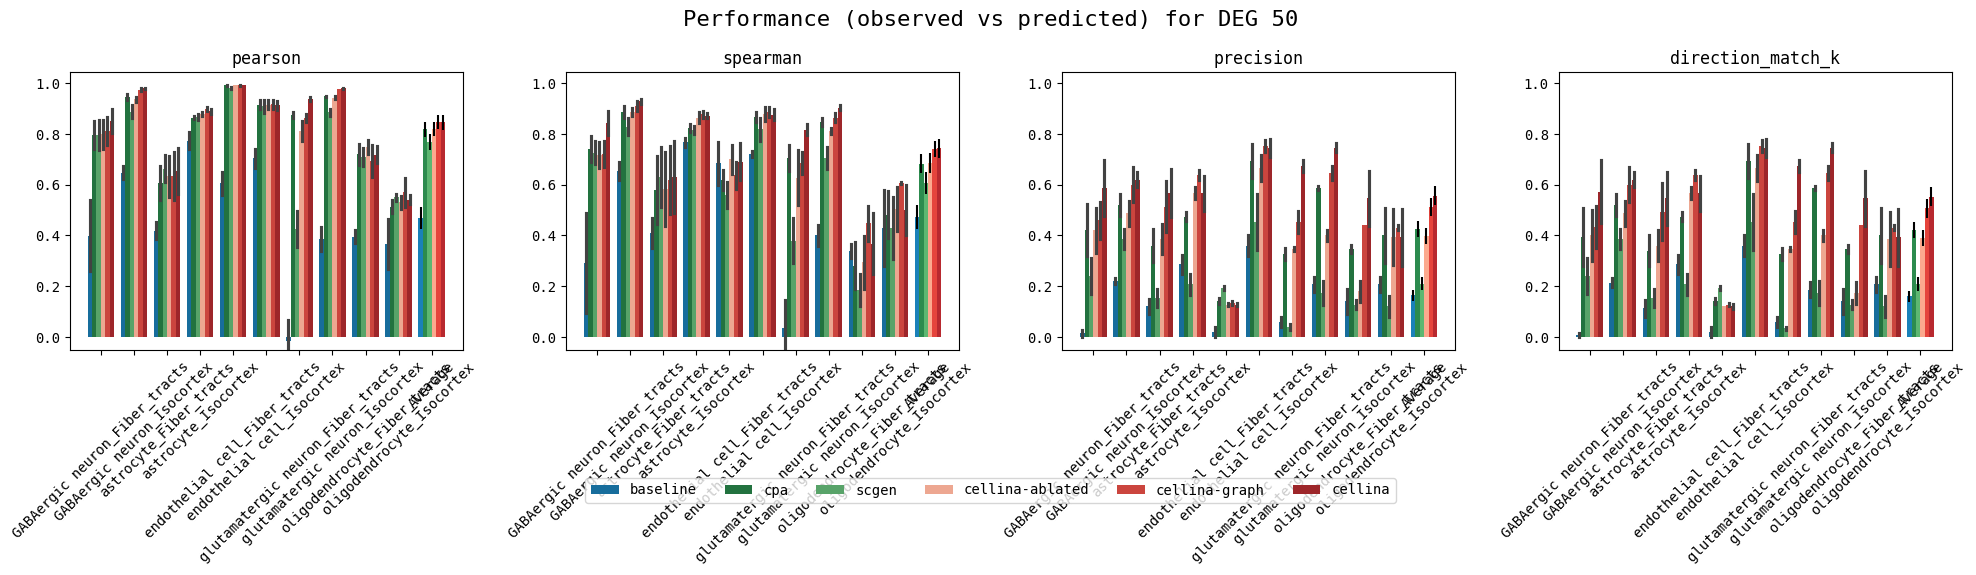

In [58]:
plot_model_comparison(
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name="ood_summary_correlations_200"
)

In [59]:
metrics = ["edistance_global", "edistance_local"]

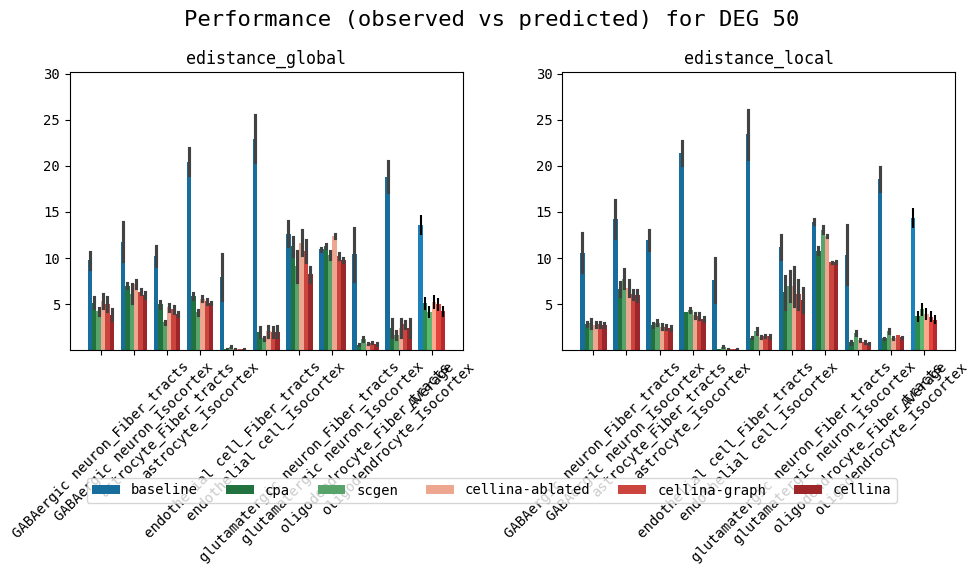

In [60]:
plot_model_comparison(
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name="ood_summary_correlations_200"
)

In [61]:
metrics = ["rmse"]

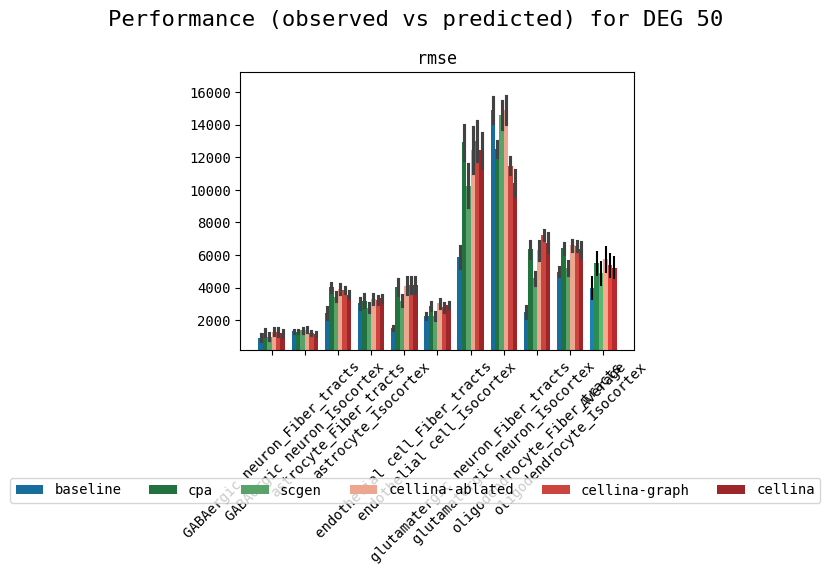

In [62]:
plot_model_comparison(
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name="ood_summary_correlations_200"
)

In [63]:
n_deg = df["n_deg"].iloc[0]
n_deg

np.int64(50)

In [64]:
n_deg = df["n_deg"].iloc[0]
df.to_csv(f"../results/loo_summary_merfish_DEG_{n_deg}.csv", index=False)